# 泰坦尼克数据集字段介绍

Survived:0代表死亡，1代表存活

Pclass:乘客所持票类，有三种值(1,2,3)

Name:乘客姓名

Sex:乘客性别

Age:乘客年龄(有缺失)

SibSp:乘客兄弟姐妹/配偶的个数(整数值)

Parch:乘客父母/孩子的个数(整数值)

Ticket:票号(字符串)

Fare:乘客所持票的价格(浮点数，0-500不等)

Cabin:乘客所在船舱(有缺失)

Embark:乘客登船港口:S、C、Q(有缺失)

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

In [2]:
data = pd.read_csv('Titanic.csv') #导入Titanic.csv文件
data.head() #展示前五行

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [28]:
#PassengerID这一列无用，删除
data.drop('PassengerId',axis=1,inplace=True) #沿着水平方向，找到'PassengerId'列并将其删除，同时在原表格将此列删除
data.head() #展示前五行

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
#检查数据，是否有空值
for col in data.columns: #遍历列名
    print(col) #打印列名
    print(data[col].isnull().sum()) #打印某一列中空值的数量，isnull()判断每个元素是否为空值，如果是数量就加1
#发现Age、Cabin和Embarked有空值

Survived
0
Pclass
0
Name
0
Sex
0
Age
177
SibSp
0
Parch
0
Ticket
0
Fare
0
Cabin
687
Embarked
2


<AxesSubplot:>

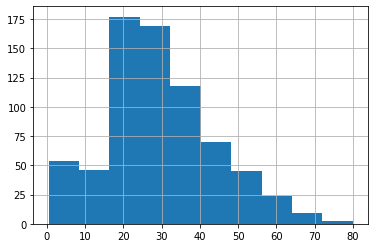

In [30]:
# 填补年龄的空值
##先画直方图看一下年龄数值分布
data['Age'].hist()

1. 处理空值方法一

In [31]:
##决定用均值加减1倍标准方差，随机生成年龄，填补空值
age_avg = data['Age'].mean() #计算年龄平均值
print(age_avg)
age_std = data['Age'].std() #计算标准差
print(age_std)
age_null_count = data['Age'].isnull().sum() #计算空值的数量
print(age_null_count)
age_null_random_list = np.random.randint(age_avg - age_std, age_avg + age_std, size=age_null_count) #均值加减1倍标准方差，随机生成年龄，生成的数量和空值数量一致
print(age_null_random_list)
data.loc[np.isnan(data['Age']), 'Age'] = age_null_random_list #判断每个元素是否有年龄，如果是Ture说明是空值，把数放到空值的位置上
data['Age'] = data['Age'].astype(int) #将数据集 data 中的 'Age' 列的数据类型转换为整数类型

29.69911764705882
14.526497332334044
177
[36 35 37 31 27 22 36 24 28 25 18 18 40 39 29 39 39 32 41 33 21 42 43 31
 29 29 32 42 15 37 35 39 42 27 24 31 30 24 42 23 23 42 32 15 20 30 36 33
 37 36 32 18 22 29 36 31 37 36 42 30 32 39 33 36 23 42 32 16 29 35 17 22
 41 28 28 37 34 36 32 26 15 38 15 43 36 33 33 40 27 37 39 42 36 21 16 40
 20 28 42 26 32 37 27 29 28 32 37 24 17 20 34 29 31 23 20 25 22 35 27 36
 39 22 25 19 39 41 36 35 30 38 39 27 36 27 18 41 19 32 23 36 32 40 25 25
 30 32 29 36 31 33 29 27 15 38 25 19 29 36 25 40 30 41 20 31 20 34 22 33
 18 29 40 17 39 32 42 41 31]


2. 处理空值方法二

In [32]:
#填补cabin空值
data['Cabin'].value_counts(dropna=False) #计算每个唯一值（包括空值）的出现次数，dropna=False指包括空值，有687人缺失

NaN            687
C23 C25 C27      4
G6               4
B96 B98          4
C22 C26          3
              ... 
E34              1
C7               1
C54              1
E36              1
C148             1
Name: Cabin, Length: 148, dtype: int64

In [33]:
# 观察到cabin有很多NaN，决定如NaN就替换成0，否则替换成1
#data['Has_Cabin']=data['Cabin'].fillna('0') #新生成一个列表，用0填充NAN
data['Has_Cabin']=data['Cabin'].apply(lambda x: 1 if type(x)==str else 0) #根据数据集 data 中的 'Cabin' 列的取值，创建一个新的列 'Has_Cabin'。判断'Cabin'列中如果是字符串，返回1；否则返回0
data.head() #打印前五行

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Has_Cabin
0,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C,1
2,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S,1
4,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S,0


In [ ]:
3. 处理空值方法三

In [34]:
#填补Embarked空值
data['Embarked'].value_counts(dropna=False) #计算每个唯一值（包括空值）的出现次数，有2人缺失

S      644
C      168
Q       77
NaN      2
Name: Embarked, dtype: int64

In [35]:
#发现S值出现的最多，所以决定用S填补空值
data['Embarked'] = data['Embarked'].fillna('S') #用最多的是填补
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Has_Cabin
0,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C,1
2,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S,1
4,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S,0


In [36]:
#对name列进行处理，name中包含了title，而title可能和类标签有关
for i in range(len(data)): 
    print(data.loc[i,'Name']) #loc定位
    title= (data.loc[i,"Name"].split(',')[1].lstrip()).split('.')[0]    #先选取'Name'列的值，按照,进行分割，选择分割后列表的第二个元素，并去除左边的空格；再按照.进行分割，选择分割后的第一个元素
    data.loc[i,'Title'] = title #创建一个新的列 'Title'，并把分割出的title值放进去
    print(data.loc[i,'Title']) #打印查看


Braund, Mr. Owen Harris
Mr
Cumings, Mrs. John Bradley (Florence Briggs Thayer)
Mrs
Heikkinen, Miss. Laina
Miss
Futrelle, Mrs. Jacques Heath (Lily May Peel)
Mrs
Allen, Mr. William Henry
Mr
Moran, Mr. James
Mr
McCarthy, Mr. Timothy J
Mr
Palsson, Master. Gosta Leonard
Master
Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
Mrs
Nasser, Mrs. Nicholas (Adele Achem)
Mrs
Sandstrom, Miss. Marguerite Rut
Miss
Bonnell, Miss. Elizabeth
Miss
Saundercock, Mr. William Henry
Mr
Andersson, Mr. Anders Johan
Mr
Vestrom, Miss. Hulda Amanda Adolfina
Miss
Hewlett, Mrs. (Mary D Kingcome) 
Mrs
Rice, Master. Eugene
Master
Williams, Mr. Charles Eugene
Mr
Vander Planke, Mrs. Julius (Emelia Maria Vandemoortele)
Mrs
Masselmani, Mrs. Fatima
Mrs
Fynney, Mr. Joseph J
Mr
Beesley, Mr. Lawrence
Mr
McGowan, Miss. Anna "Annie"
Miss
Sloper, Mr. William Thompson
Mr
Palsson, Miss. Torborg Danira
Miss
Asplund, Mrs. Carl Oscar (Selma Augusta Emilia Johansson)
Mrs
Emir, Mr. Farred Chehab
Mr
Fortune, Mr. Charles Alexander
Mr
O'

Svensson, Mr. Olof
Mr
Calic, Mr. Petar
Mr
Canavan, Miss. Mary
Miss
O'Sullivan, Miss. Bridget Mary
Miss
Laitinen, Miss. Kristina Sofia
Miss
Maioni, Miss. Roberta
Miss
Penasco y Castellana, Mr. Victor de Satode
Mr
Quick, Mrs. Frederick Charles (Jane Richards)
Mrs
Bradley, Mr. George ("George Arthur Brayton")
Mr
Olsen, Mr. Henry Margido
Mr
Lang, Mr. Fang
Mr
Daly, Mr. Eugene Patrick
Mr
Webber, Mr. James
Mr
McGough, Mr. James Robert
Mr
Rothschild, Mrs. Martin (Elizabeth L. Barrett)
Mrs
Coleff, Mr. Satio
Mr
Walker, Mr. William Anderson
Mr
Lemore, Mrs. (Amelia Milley)
Mrs
Ryan, Mr. Patrick
Mr
Angle, Mrs. William A (Florence "Mary" Agnes Hughes)
Mrs
Pavlovic, Mr. Stefo
Mr
Perreault, Miss. Anne
Miss
Vovk, Mr. Janko
Mr
Lahoud, Mr. Sarkis
Mr
Hippach, Mrs. Louis Albert (Ida Sophia Fischer)
Mrs
Kassem, Mr. Fared
Mr
Farrell, Mr. James
Mr
Ridsdale, Miss. Lucy
Miss
Farthing, Mr. John
Mr
Salonen, Mr. Johan Werner
Mr
Hocking, Mr. Richard George
Mr
Quick, Miss. Phyllis May
Miss
Toufik, Mr. Nakli
Mr
Elias

Mr
Tobin, Mr. Roger
Mr
Emanuel, Miss. Virginia Ethel
Miss
Kilgannon, Mr. Thomas J
Mr
Robert, Mrs. Edward Scott (Elisabeth Walton McMillan)
Mrs
Ayoub, Miss. Banoura
Miss
Dick, Mrs. Albert Adrian (Vera Gillespie)
Mrs
Long, Mr. Milton Clyde
Mr
Johnston, Mr. Andrew G
Mr
Ali, Mr. William
Mr
Harmer, Mr. Abraham (David Lishin)
Mr
Sjoblom, Miss. Anna Sofia
Miss
Rice, Master. George Hugh
Master
Dean, Master. Bertram Vere
Master
Guggenheim, Mr. Benjamin
Mr
Keane, Mr. Andrew "Andy"
Mr
Gaskell, Mr. Alfred
Mr
Sage, Miss. Stella Anna
Miss
Hoyt, Mr. William Fisher
Mr
Dantcheff, Mr. Ristiu
Mr
Otter, Mr. Richard
Mr
Leader, Dr. Alice (Farnham)
Dr
Osman, Mrs. Mara
Mrs
Ibrahim Shawah, Mr. Yousseff
Mr
Van Impe, Mrs. Jean Baptiste (Rosalie Paula Govaert)
Mrs
Ponesell, Mr. Martin
Mr
Collyer, Mrs. Harvey (Charlotte Annie Tate)
Mrs
Carter, Master. William Thornton II
Master
Thomas, Master. Assad Alexander
Master
Hedman, Mr. Oskar Arvid
Mr
Johansson, Mr. Karl Johan
Mr
Andrews, Mr. Thomas Jr
Mr
Pettersson, Miss.

In [37]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Has_Cabin,Title
0,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S,0,Mr
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C,1,Mrs
2,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S,0,Miss
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S,1,Mrs
4,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S,0,Mr


In [38]:
data['Title'].value_counts() #计算不同title的数量

Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: Title, dtype: int64

In [39]:
#对出现较少的title统一改为rare；对拼写错误的进行修正
data['Title'] = data['Title'].replace(['Lady', 'the Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
data['Title'] = data['Title'].replace('Mlle', 'Miss')
data['Title'] = data['Title'].replace('Ms', 'Miss')
data['Title'] = data['Title'].replace('Mme', 'Mrs')

In [40]:
data['Title'].value_counts() #再次计算不同title的数量

Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: Title, dtype: int64

one-hot encode Title column 独热编码

In [41]:
# one-hot encode Title column 独热编码
ohe_Title = pd.get_dummies(data['Title'], prefix='Title') #对数据集中的 'Title' 列进行独热编码，并将其赋值给变量 'ohe_Title'
data = pd.concat([data, ohe_Title], axis=1).drop(['Title'], axis=1) # 将数据集 data与 'ohe_Title' 沿着列方向拼接，并删除原始的 'Title' 列

In [42]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Has_Cabin,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S,0,0,0,1,0,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C,1,0,0,0,1,0
2,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S,0,0,1,0,0,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S,1,0,0,0,1,0
4,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S,0,0,0,1,0,0


In [43]:
# 票价分段
data.loc[ data['Fare'] <= 7.91, 'Fare']  = 0
data.loc[(data['Fare'] > 7.91) & (data['Fare'] <= 14.454), 'Fare'] = 1
data.loc[(data['Fare'] > 14.454) & (data['Fare'] <= 31), 'Fare']   = 2
data.loc[ data['Fare'] > 31, 'Fare']   = 3

data['Fare'].value_counts() #计数

2.0    229
0.0    223
3.0    222
1.0    217
Name: Fare, dtype: int64

In [44]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Has_Cabin,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,0.0,NaN,S,0,0,0,1,0,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,3.0,C85,C,1,0,0,0,1,0
2,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,1.0,NaN,S,0,0,1,0,0,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,3.0,C123,S,1,0,0,0,1,0
4,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,1.0,NaN,S,0,0,0,1,0,0


In [45]:
# 年龄分段
data.loc[ data['Age'] <= 16, 'Age']   = 0
data.loc[(data['Age'] > 16) & (data['Age'] <= 32), 'Age'] = 1
data.loc[(data['Age'] > 32) & (data['Age'] <= 48), 'Age'] = 2
data.loc[(data['Age'] > 48) & (data['Age'] <= 64), 'Age'] = 3
data.loc[ data['Age'] > 64, 'Age']=4

In [46]:
data['Age'].value_counts() #计数

1    442
2    262
0    107
3     69
4     11
Name: Age, dtype: int64

In [47]:
# one-hot encode Sex column
ohe_Sex = pd.get_dummies(data['Sex'], prefix='Sex') #将名为'Sex'的列转换成独热编码，并将其赋值给变量'ohe_Sex'
data = pd.concat([data, ohe_Sex], axis=1).drop(['Sex'], axis=1) #将数据集'data'和独热编码结果ohe_Sex沿着列方向拼接，并删除'Sex'列

In [48]:
# one-hot encode Embarked column
ohe_Embarked = pd.get_dummies(data['Embarked'], prefix='Embarked') #将名为'Embarked'的列转换成独热编码，并将其赋值给变量'ohe_Embarked'
data = pd.concat([data, ohe_Embarked], axis=1).drop(['Embarked'], axis=1) #将数据集'data'和独热编码结果ohe_Embarked沿着列方向拼接，并删除'Embarked'列

In [49]:
data.head() #显示前五行

,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Has_Cabin,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,"Braund, Mr. Owen Harris",1,1,0,A/5 21171,0.0,NaN,0,0,0,1,0,0,0,1,0,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",2,1,0,PC 17599,3.0,C85,1,0,0,0,1,0,1,0,1,0,0
2,1,3,"Heikkinen, Miss. Laina",1,0,0,STON/O2. 3101282,1.0,NaN,0,0,1,0,0,0,1,0,0,0,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",2,1,0,113803,3.0,C123,1,0,0,0,1,0,1,0,0,0,1
4,0,3,"Allen, Mr. William Henry",2,0,0,373450,1.0,NaN,0,0,0,1,0,0,0,1,0,0,1


In [50]:
# 删掉没用的列
data = data.drop( [ 'Name','SibSp', 'Ticket', 'Cabin'], axis = 1) #沿着列的方向，删除'Name'、'SibSp'、'Ticket'和'Cabin'列

In [51]:
data.head(3) #显示前3行

,Survived,Pclass,Age,Parch,Fare,Has_Cabin,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,0,0.0,0,0,0,1,0,0,0,1,0,0,1
1,1,1,2,0,3.0,1,0,0,0,1,0,1,0,1,0,0
2,1,3,1,0,1.0,0,0,1,0,0,0,1,0,0,0,1


In [52]:
data.corr() #计算元素之间的相关度

,Survived,Pclass,Age,Parch,Fare,Has_Cabin,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
Survived,1.000000,-0.338481,-0.058240,0.081629,0.295875,0.316912,0.085221,0.335636,-0.549199,0.341994,-0.012054,0.543351,-0.543351,0.168240,0.003650,-0.149683
Pclass,-0.338481,1.000000,-0.315384,0.018443,-0.628459,-0.725541,0.082081,-0.010261,0.142698,-0.153758,-0.187174,-0.131900,0.131900,-0.243292,0.221009,0.074053
Age,-0.058240,-0.315384,1.000000,-0.147077,0.073587,0.218075,-0.314812,-0.230285,0.157086,0.149630,0.182439,-0.078242,0.078242,0.046370,-0.043756,-0.013086
Parch,0.081629,0.018443,-0.147077,1.000000,0.393048,0.036987,0.267344,0.100998,-0.333905,0.223575,-0.059535,0.245489,-0.245489,-0.011069,-0.081228,0.060814
Fare,0.295875,-0.628459,0.073587,0.393048,1.000000,0.497108,0.154223,0.060825,-0.323790,0.260449,0.078429,0.248940,-0.248940,0.200659,-0.242653,-0.023084
Has_Cabin,0.316912,-0.725541,0.218075,0.036987,0.497108,1.000000,-0.027841,0.043749,-0.137319,0.123817,0.079742,0.140391,-0.140391,0.208528,-0.129572,-0.101139
Title_Master,0.085221,0.082081,-0.314812,0.267344,0.154223,-0.027841,1.000000,-0.110981,-0.254903,-0.087987,-0.035291,-0.159934,0.159934,-0.035225,0.010478,0.024264
Title_Miss,0.335636,-0.010261,-0.230285,0.100998,0.060825,0.043749,-0.110981,1.000000,-0.601857,-0.207749,-0.083327,0.693916,-0.693916,0.036204,0.167531,-0.137144
Title_Mr,-0.549199,0.142698,0.157086,-0.333905,-0.323790,-0.137319,-0.254903,-0.601857,1.000000,-0.477160,-0.191387,-0.867334,0.867334,-0.072567,-0.078338,0.112870
Title_Mrs,0.341994,-0.153758,0.149630,0.223575,0.260449,0.123817,-0.087987,-0.207749,-0.477160,1.000000,-0.066063,0.550146,-0.550146,0.067872,-0.090432,-0.002550


<AxesSubplot:title={'center':'Pearson Correlation of Features'}>

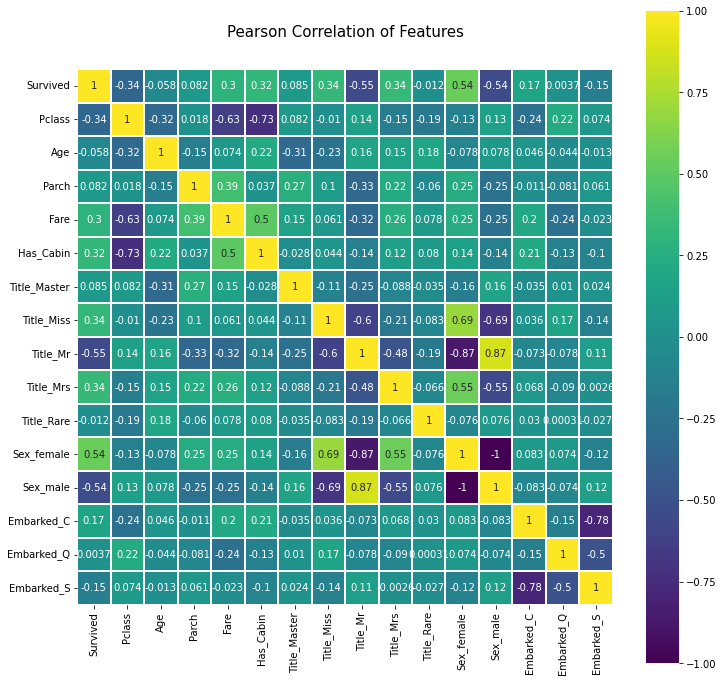

In [53]:
import seaborn as sns #导入Seaborn库
import matplotlib.pyplot as plt
colormap = plt.cm.viridis #使用Viridis颜色映射
plt.figure(figsize=(12,12)) #创建一个12*12的画布
plt.title('Pearson Correlation of Features', y=1.05, size=15) #设置标题内容、位置、字体大小
sns.heatmap(data.corr(),linewidths=0.1,vmax=1.0, square=True, cmap=colormap, linecolor='white', annot=True) #绘制相关性矩阵热力图，分割线的宽度0.1，热力图中颜色映射的最大值是1，形状方形，分割线白色，显示数值

In [54]:
from sklearn import linear_model #从sklearn库中导入了linear_model模块
from sklearn.model_selection import train_test_split #从model_selection模块中导入train_test_split函数

C:\Users\frees\AppData\Roaming\Python\Python37\site-packages\sklearn\linear_model\least_angle.py:30: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  method='lar', copy_X=True, eps=np.finfo(np.float).eps,
C:\Users\frees\AppData\Roaming\Python\Python37\site-packages\sklearn\linear_model\least_angle.py:167: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#depre

In [55]:
y=data['Survived'] #选择'Survive'特征
X=data.drop('Survived',axis=1) #删标签

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1) #划分训练集和测试集，划分成测试集的比例为20%
print(len(X_train))
print(len(y_train))
print(len(X_test))
print(len(y_test))

712
712
179
179


In [57]:
logreg=linear_model.LogisticRegression(C=1e5) #创建模型对象

In [58]:
logreg.fit(X_train,y_train) #训练

C:\Users\frees\AppData\Roaming\Python\Python37\site-packages\sklearn\linear_model\logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


LogisticRegression(C=100000.0, class_weight=None, dual=False,
                   fit_intercept=True, intercept_scaling=1, l1_ratio=None,
                   max_iter=100, multi_class='warn', n_jobs=None, penalty='l2',
                   random_state=None, solver='warn', tol=0.0001, verbose=0,
                   warm_start=False)

In [59]:
prepro = logreg.predict_proba(X_test) #对测试集的X_test进行预测，获得预测结果的概率值
print(prepro)

[[0.02531488 0.97468512]
 [0.90243027 0.09756973]
 [0.20408652 0.79591348]
 [0.39195274 0.60804726]
 [0.31365217 0.68634783]
 [0.92739231 0.07260769]
 [0.8848125  0.1151875 ]
 [0.03464553 0.96535447]
 [0.6229695  0.3770305 ]
 [0.55158228 0.44841772]
 [0.92739231 0.07260769]
 [0.46390577 0.53609423]
 [0.70918743 0.29081257]
 [0.87837862 0.12162138]
 [0.31810226 0.68189774]
 [0.4806302  0.5193698 ]
 [0.52123269 0.47876731]
 [0.96061152 0.03938848]
 [0.94634779 0.05365221]
 [0.25877259 0.74122741]
 [0.94637894 0.05362106]
 [0.93159243 0.06840757]
 [0.03382526 0.96617474]
 [0.90897424 0.09102576]
 [0.32591942 0.67408058]
 [0.94637894 0.05362106]
 [0.05869547 0.94130453]
 [0.12799312 0.87200688]
 [0.83948258 0.16051742]
 [0.12669818 0.87330182]
 [0.46390577 0.53609423]
 [0.5610104  0.4389896 ]
 [0.80017207 0.19982793]
 [0.46390577 0.53609423]
 [0.92927494 0.07072506]
 [0.68061804 0.31938196]
 [0.5610104  0.4389896 ]
 [0.94634779 0.05365221]
 [0.41658524 0.58341476]
 [0.92739231 0.07260769]


In [60]:
preclass = logreg.predict(X_test) #获得分类预测结果
print(preclass)

[1 0 1 1 1 0 0 1 0 0 0 1 0 0 1 1 0 0 0 1 0 0 1 0 1 0 1 1 0 1 1 0 0 1 0 0 0
 0 1 0 1 1 1 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 1 0
 1 0 1 0 1 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 1 0 0 0 0 1 1 1 1 1 0 0 1 1 0 1 1 0 1 0 0
 0 0 1 0 1 1 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 1 0 1 0 1 1 0 0 1]


C:\Users\frees\AppData\Roaming\Python\Python37\site-packages\sklearn\linear_model\base.py:291: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  indices = (scores > 0).astype(np.int)


In [61]:
acc = logreg.score(X_test,y_test) #利用测试集算模型的准确率
print(acc)

0.7988826815642458


C:\Users\frees\AppData\Roaming\Python\Python37\site-packages\sklearn\linear_model\base.py:291: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  indices = (scores > 0).astype(np.int)


In [62]:
from sklearn.model_selection import cross_val_score #从sklearn.model_selection模块中导入cross_val_score函数

In [63]:
scores = cross_val_score(logreg, X_train, y_train, cv=5) #利用5折交叉验证对模型进行评分
scores

C:\Users\frees\AppData\Roaming\Python\Python37\site-packages\sklearn\model_selection\_split.py:670: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  test_folds = np.zeros(n_samples, dtype=np.int)
C:\Users\frees\AppData\Roaming\Python\Python37\site-packages\sklearn\model_selection\_split.py:442: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify 

array([0.79020979, 0.82517483, 0.83916084, 0.81690141, 0.81560284])

In [64]:
 print("Accuracy: %0.2f (+/- %0.2f)" % (scores.mean(), scores.std() * 2)) #计算交叉验证得分的平均准确率，并计算置信区间

Accuracy: 0.82 (+/- 0.03)
